In [8]:
# CELL 1: Setup (already ran successfully)
import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from src.config import *

print("✅ Setup complete!")

✅ Setup complete!


In [2]:
# CELL 2: Verify all paths exist
print("=" * 50)
print("CHECKING PATHS")
print("=" * 50)

paths_to_check = {
    "Control Audio": CONTROL_AUDIO_PATH,
    "Dementia Audio": DEMENTIA_AUDIO_PATH,
    "Control Transcripts": CONTROL_TRANSCRIPT_PATH,
    "Dementia Transcripts": DEMENTIA_TRANSCRIPT_PATH,
    "Processed": PROCESSED_PATH
}

for name, path in paths_to_check.items():
    if os.path.exists(path):
        print(f"✅ {name}: EXISTS")
        print(f"   Location: {path}")
    else:
        print(f"❌ {name}: NOT FOUND")
        print(f"   Tried: {path}")

print("\n" + "=" * 50)

CHECKING PATHS
✅ Control Audio: EXISTS
   Location: C:\alzheimers_detection\data\raw\Control
✅ Dementia Audio: EXISTS
   Location: C:\alzheimers_detection\data\raw\Dementia
✅ Control Transcripts: EXISTS
   Location: C:\alzheimers_detection\data\raw\transcripts\Control_transcripts
✅ Dementia Transcripts: EXISTS
   Location: C:\alzheimers_detection\data\raw\transcripts\Dementia_transcripts
✅ Processed: EXISTS
   Location: C:\alzheimers_detection\data\processed



In [9]:
# CELL 2: Get Accurate File Counts
print("=" * 60)
print("FILE COUNTS (ACCURATE)")
print("=" * 60)

from pathlib import Path

# Audio files
control_audio = list(Path(CONTROL_AUDIO_PATH).glob("*.mp3")) + list(Path(CONTROL_AUDIO_PATH).glob("*.wav"))
dementia_audio = list(Path(DEMENTIA_AUDIO_PATH).glob("*.mp3")) + list(Path(DEMENTIA_AUDIO_PATH).glob("*.wav"))

# Transcript files
control_trans = list(Path(CONTROL_TRANSCRIPT_PATH).glob("*.cha")) + list(Path(CONTROL_TRANSCRIPT_PATH).glob("*.txt"))
dementia_trans = list(Path(DEMENTIA_TRANSCRIPT_PATH).glob("*.cha")) + list(Path(DEMENTIA_TRANSCRIPT_PATH).glob("*.txt"))

print(f"CONTROL:")
print(f"  Audio files: {len(control_audio)}")
print(f"  Transcripts: {len(control_trans)}")
print(f"\nDEMENTIA:")
print(f"  Audio files: {len(dementia_audio)}")
print(f"  Transcripts: {len(dementia_trans)}")

FILE COUNTS (ACCURATE)
CONTROL:
  Audio files: 219
  Transcripts: 243

DEMENTIA:
  Audio files: 222
  Transcripts: 309


In [11]:
# CELL 3: Create Matched Dataset (Only files with BOTH audio AND transcript)
print("=" * 60)
print("CREATING MATCHED DATASET")
print("=" * 60)

def extract_patient_id(filename):
    """Extract patient ID from filename like '002-0.mp3' -> '002'"""
    name = filename.stem
    if '-' in name:
        return name.split('-')[0]
    return name

def extract_session(filename):
    """Extract session number from filename like '002-0.mp3' -> '0'"""
    name = filename.stem
    if '-' in name:
        parts = name.split('-')
        if len(parts) > 1:
            return parts[1]
    return '0'

# Create lookup dictionaries for transcripts
control_trans_dict = {f.stem: f for f in control_trans}
dementia_trans_dict = {f.stem: f for f in dementia_trans}

# Build matched dataset
matched_data = []

# Process Control
for audio in control_audio:
    stem = audio.stem
    if stem in control_trans_dict:
        matched_data.append({
            'patient_id': extract_patient_id(audio),
            'session': extract_session(audio),
            'class': 'Control',
            'audio_path': str(audio),
            'transcript_path': str(control_trans_dict[stem]),
            'audio_file': audio.name,
            'transcript_file': control_trans_dict[stem].name
        })

# Process Dementia
for audio in dementia_audio:
    stem = audio.stem
    if stem in dementia_trans_dict:
        matched_data.append({
            'patient_id': extract_patient_id(audio),
            'session': extract_session(audio),
            'class': 'Dementia',
            'audio_path': str(audio),
            'transcript_path': str(dementia_trans_dict[stem]),
            'audio_file': audio.name,
            'transcript_file': dementia_trans_dict[stem].name
        })

df = pd.DataFrame(matched_data)

print(f"\n✅ Total matched samples: {len(df)}")
print(f"\n📊 Class distribution:")
print(df['class'].value_counts())

print(f"\n📊 Patient statistics:")
print(f"  Control patients: {df[df['class']=='Control']['patient_id'].nunique()}")
print(f"  Dementia patients: {df[df['class']=='Dementia']['patient_id'].nunique()}")

print(f"\n📁 First 10 samples:")
print(df[['patient_id', 'session', 'class', 'audio_file']].head(10))

# Save matched dataset
os.makedirs(METADATA_PATH, exist_ok=True)
df.to_csv(os.path.join(METADATA_PATH, 'matched_dataset.csv'), index=False)
print(f"\n💾 Saved to: {os.path.join(METADATA_PATH, 'matched_dataset.csv')}")

CREATING MATCHED DATASET

✅ Total matched samples: 439

📊 Class distribution:
class
Dementia    222
Control     217
Name: count, dtype: int64

📊 Patient statistics:
  Control patients: 94
  Dementia patients: 124

📁 First 10 samples:
  patient_id session    class audio_file
0        002       0  Control  002-0.mp3
1        002       1  Control  002-1.mp3
2        002       2  Control  002-2.mp3
3        002       3  Control  002-3.mp3
4        006       2  Control  006-2.mp3
5        006       3  Control  006-3.mp3
6        006       4  Control  006-4.mp3
7        013       0  Control  013-0.mp3
8        013       2  Control  013-2.mp3
9        013       3  Control  013-3.mp3

💾 Saved to: C:\alzheimers_detection\data\processed\metadata\matched_dataset.csv


In [10]:
# CELL: Accurate File Count Diagnostic
print("=" * 60)
print("ACCURATE FILE COUNT DIAGNOSTIC")
print("=" * 60)

import os
from pathlib import Path

# Control Audio
control_audio_path = r"C:\alzheimers_detection\data\raw\Control"
control_audio_files = list(Path(control_audio_path).glob("*.mp3")) + list(Path(control_audio_path).glob("*.wav"))

# Dementia Audio  
dementia_audio_path = r"C:\alzheimers_detection\data\raw\Dementia"
dementia_audio_files = list(Path(dementia_audio_path).glob("*.mp3")) + list(Path(dementia_audio_path).glob("*.wav"))

print(f"📁 CONTROL AUDIO:")
print(f"   Path: {control_audio_path}")
print(f"   Total files: {len(control_audio_files)}")
print(f"   Sample: {[f.name for f in control_audio_files[:5]]}")

print(f"\n📁 DEMENTIA AUDIO:")
print(f"   Path: {dementia_audio_path}")
print(f"   Total files: {len(dementia_audio_files)}")
print(f"   Sample: {[f.name for f in dementia_audio_files[:5]]}")

# Now let's count UNIQUE patients (not sessions)
def get_unique_patients(files):
    patients = set()
    for f in files:
        # Extract patient ID (e.g., "002" from "002-0.mp3")
        name = f.stem
        if '-' in name:
            patient_id = name.split('-')[0]
        else:
            patient_id = name
        patients.add(patient_id)
    return patients

control_patients = get_unique_patients(control_audio_files)
dementia_patients = get_unique_patients(dementia_audio_files)

print(f"\n👥 UNIQUE PATIENTS:")
print(f"   Control patients: {len(control_patients)}")
print(f"   Dementia patients: {len(dementia_patients)}")
print(f"   Total patients: {len(control_patients) + len(dementia_patients)}")

# Count sessions per patient
from collections import Counter

control_sessions = Counter()
for f in control_audio_files:
    name = f.stem
    if '-' in name:
        patient_id = name.split('-')[0]
        control_sessions[patient_id] += 1

dementia_sessions = Counter()
for f in dementia_audio_files:
    name = f.stem
    if '-' in name:
        patient_id = name.split('-')[0]
        dementia_sessions[patient_id] += 1

print(f"\n📊 SESSIONS PER PATIENT:")
if control_sessions:
    print(f"   Control: min={min(control_sessions.values())}, max={max(control_sessions.values())}, avg={sum(control_sessions.values())/len(control_sessions):.1f}")
if dementia_sessions:
    print(f"   Dementia: min={min(dementia_sessions.values())}, max={max(dementia_sessions.values())}, avg={sum(dementia_sessions.values())/len(dementia_sessions):.1f}")

# Now transcripts
control_trans_path = r"C:\alzheimers_detection\data\raw\transcripts\Control_transcripts"
dementia_trans_path = r"C:\alzheimers_detection\data\raw\transcripts\Dementia_transcripts"

control_trans_files = list(Path(control_trans_path).glob("*.cha")) + list(Path(control_trans_path).glob("*.txt"))
dementia_trans_files = list(Path(dementia_trans_path).glob("*.cha")) + list(Path(dementia_trans_path).glob("*.txt"))

print(f"\n📄 TRANSCRIPTS:")
print(f"   Control transcripts: {len(control_trans_files)}")
print(f"   Dementia transcripts: {len(dementia_trans_files)}")

# Get unique patients from transcripts
control_trans_patients = get_unique_patients(control_trans_files)
dementia_trans_patients = get_unique_patients(dementia_trans_files)

print(f"\n👥 UNIQUE PATIENTS (from transcripts):")
print(f"   Control: {len(control_trans_patients)}")
print(f"   Dementia: {len(dementia_trans_patients)}")

ACCURATE FILE COUNT DIAGNOSTIC
📁 CONTROL AUDIO:
   Path: C:\alzheimers_detection\data\raw\Control
   Total files: 219
   Sample: ['002-0.mp3', '002-1.mp3', '002-2.mp3', '002-3.mp3', '006-2.mp3']

📁 DEMENTIA AUDIO:
   Path: C:\alzheimers_detection\data\raw\Dementia
   Total files: 222
   Sample: ['001-0.mp3', '001-2.mp3', '003-0.mp3', '005-0.mp3', '005-2.mp3']

👥 UNIQUE PATIENTS:
   Control patients: 94
   Dementia patients: 124
   Total patients: 218

📊 SESSIONS PER PATIENT:
   Control: min=1, max=5, avg=2.3
   Dementia: min=1, max=5, avg=1.8

📄 TRANSCRIPTS:
   Control transcripts: 243
   Dementia transcripts: 309

👥 UNIQUE PATIENTS (from transcripts):
   Control: 99
   Dementia: 194


In [14]:
# CELL 3: Create Matched Dataset (Only files with BOTH audio AND transcript)
print("=" * 60)
print("CREATING MATCHED DATASET")
print("=" * 60)

def extract_patient_id(filename):
    """Extract patient ID from filename like '002-0.mp3' -> '002'"""
    name = filename.stem
    if '-' in name:
        return name.split('-')[0]
    return name

def extract_session(filename):
    """Extract session number from filename like '002-0.mp3' -> '0'"""
    name = filename.stem
    if '-' in name:
        parts = name.split('-')
        if len(parts) > 1:
            return parts[1]
    return '0'

# Create lookup dictionaries for transcripts
control_trans_dict = {f.stem: f for f in control_trans}
dementia_trans_dict = {f.stem: f for f in dementia_trans}

# Build matched dataset
matched_data = []

# Process Control
for audio in control_audio:
    stem = audio.stem
    if stem in control_trans_dict:
        matched_data.append({
            'patient_id': extract_patient_id(audio),
            'session': extract_session(audio),
            'class': 'Control',
            'audio_path': str(audio),
            'transcript_path': str(control_trans_dict[stem]),
            'audio_file': audio.name,
            'transcript_file': control_trans_dict[stem].name
        })

# Process Dementia
for audio in dementia_audio:
    stem = audio.stem
    if stem in dementia_trans_dict:
        matched_data.append({
            'patient_id': extract_patient_id(audio),
            'session': extract_session(audio),
            'class': 'Dementia',
            'audio_path': str(audio),
            'transcript_path': str(dementia_trans_dict[stem]),
            'audio_file': audio.name,
            'transcript_file': dementia_trans_dict[stem].name
        })

df = pd.DataFrame(matched_data)

print(f"\n✅ Total matched samples: {len(df)}")
print(f"\n📊 Class distribution:")
print(df['class'].value_counts())

print(f"\n📊 Patient statistics:")
print(f"  Control patients: {df[df['class']=='Control']['patient_id'].nunique()}")
print(f"  Dementia patients: {df[df['class']=='Dementia']['patient_id'].nunique()}")

print(f"\n📁 First 10 samples:")
print(df[['patient_id', 'session', 'class', 'audio_file']].head(10))

# Save matched dataset
os.makedirs(METADATA_PATH, exist_ok=True)
df.to_csv(os.path.join(METADATA_PATH, 'matched_dataset.csv'), index=False)
print(f"\n💾 Saved to: {os.path.join(METADATA_PATH, 'matched_dataset.csv')}")

CREATING MATCHED DATASET

✅ Total matched samples: 439

📊 Class distribution:
class
Dementia    222
Control     217
Name: count, dtype: int64

📊 Patient statistics:
  Control patients: 94
  Dementia patients: 124

📁 First 10 samples:
  patient_id session    class audio_file
0        002       0  Control  002-0.mp3
1        002       1  Control  002-1.mp3
2        002       2  Control  002-2.mp3
3        002       3  Control  002-3.mp3
4        006       2  Control  006-2.mp3
5        006       3  Control  006-3.mp3
6        006       4  Control  006-4.mp3
7        013       0  Control  013-0.mp3
8        013       2  Control  013-2.mp3
9        013       3  Control  013-3.mp3

💾 Saved to: C:\alzheimers_detection\data\processed\metadata\matched_dataset.csv


SAMPLE FILE INSPECTION

--- CONTROL SAMPLE ---
Patient: 002, Session: 0
Audio: 002-0.mp3
Transcript: 002-0.cha

Audio: 62.74 seconds, 16000 Hz
Transcript: 215 words

First 300 chars: the scene is <in the> [/] in the kitchen . 3754_5640 the mother is wiping dishes and the water is running on the floor . 5776_11843 <a child is tryin(g) to get> [//] a boy is tryin(g) to get cookies outta [: out of] a jar and he's about to tip over on a stool . 12138_17928 &-uh the little girl...

--- DEMENTIA SAMPLE ---
Patient: 001, Session: 0
Audio: 001-0.mp3
Transcript: 001-0.cha

Audio: 55.19 seconds, 16000 Hz
Transcript: 157 words

First 300 chars: *INV:	this is the picture . 1360_2530 mhm . [+ exc] 2821_3211 *INV:	just tell me everything that you see happening in that picture . 4022_6646 +< alright . [+ exc] 6650_6820 there's &-um a young boy that's getting a cookie jar . 7277_12026 and it [//] he's &-uh in bad shape because &-uh th...


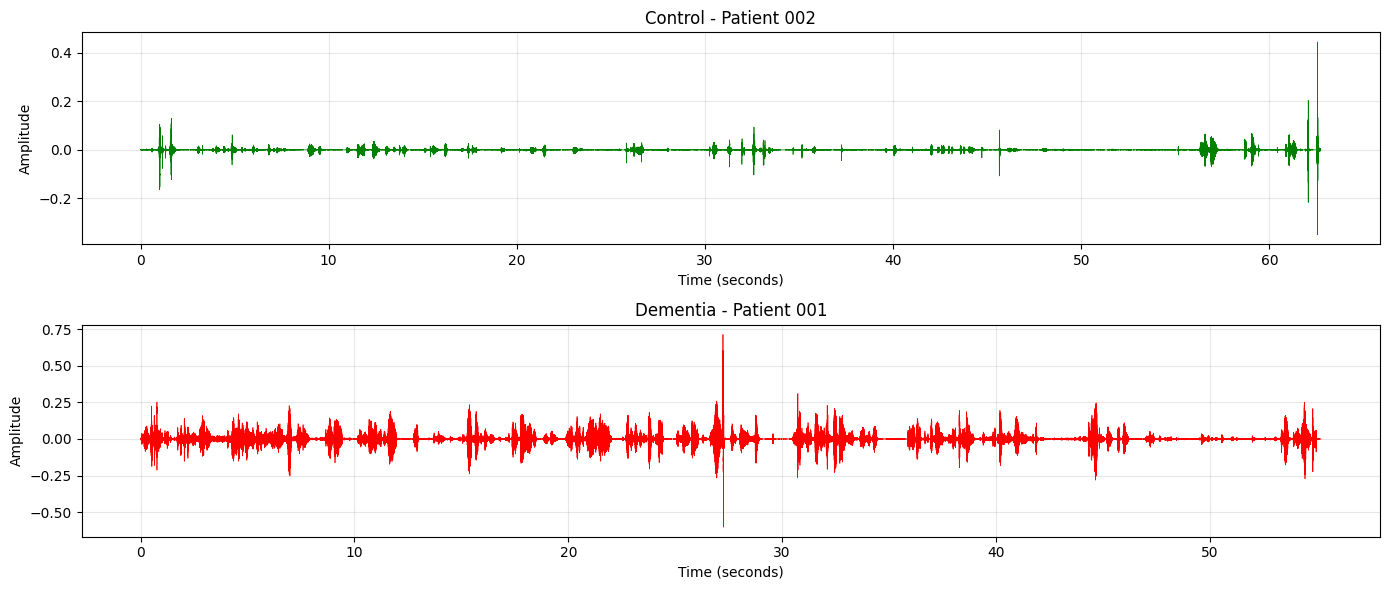

In [15]:
# CELL 4: Inspect a sample audio and its transcript
print("=" * 60)
print("SAMPLE FILE INSPECTION")
print("=" * 60)

# Pick one sample from each class
control_sample = df[df['class'] == 'Control'].iloc[0] if len(df[df['class']=='Control']) > 0 else None
dementia_sample = df[df['class'] == 'Dementia'].iloc[0] if len(df[df['class']=='Dementia']) > 0 else None

def inspect_sample(sample, label):
    if sample is None:
        print(f"No {label} samples found")
        return None, None, None
    
    print(f"\n--- {label} SAMPLE ---")
    print(f"Patient: {sample['patient_id']}, Session: {sample['session']}")
    print(f"Audio: {sample['audio_file']}")
    print(f"Transcript: {sample['transcript_file']}")
    
    # Load audio
    audio, sr = librosa.load(sample['audio_path'], sr=SAMPLE_RATE)
    print(f"\nAudio: {len(audio)/sr:.2f} seconds, {sr} Hz")
    
    # Read transcript
    with open(sample['transcript_path'], 'r', encoding='utf-8', errors='ignore') as f:
        transcript_content = f.read()
    
    # Extract spoken content (skip CHAT headers)
    lines = transcript_content.split('\n')
    spoken_parts = []
    for line in lines:
        if line.startswith('*PAR:') or line.startswith('*PAT:') or line.startswith('*CHI:'):
            text = line.split(':', 1)[-1].strip()
            spoken_parts.append(text)
        elif line.strip() and not line.startswith('@') and not line.startswith('%'):
            if len(line.strip()) > 10:
                spoken_parts.append(line.strip())
    
    spoken_text = ' '.join(spoken_parts)
    print(f"Transcript: {len(spoken_text.split())} words")
    print(f"\nFirst 300 chars: {spoken_text[:300]}...")
    
    return audio, sr, spoken_text

# Inspect both samples
control_audio, control_sr, control_text = inspect_sample(control_sample, "CONTROL")
dementia_audio, dementia_sr, dementia_text = inspect_sample(dementia_sample, "DEMENTIA")

# Plot waveforms if we have both
if control_audio is not None and dementia_audio is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))
    
    time_c = np.arange(len(control_audio)) / control_sr
    axes[0].plot(time_c, control_audio, linewidth=0.5, color='green')
    axes[0].set_title(f"Control - Patient {control_sample['patient_id']}")
    axes[0].set_xlabel("Time (seconds)")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)
    
    time_d = np.arange(len(dementia_audio)) / dementia_sr
    axes[1].plot(time_d, dementia_audio, linewidth=0.5, color='red')
    axes[1].set_title(f"Dementia - Patient {dementia_sample['patient_id']}")
    axes[1].set_xlabel("Time (seconds)")
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [16]:
# CELL 5: Final Dataset Summary
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)

print(f"""
┌─────────────────────────────────────────────────────────────┐
│              MATCHED DATASET STATISTICS                      │
├─────────────────────────────────────────────────────────────┤
│ Total matched samples (audio + transcript): {len(df)}                    │
│                                                             │
│ Class Distribution:                                         │
│   • Control (Healthy):  {len(df[df['class']=='Control'])} samples                          │
│   • Dementia:           {len(df[df['class']=='Dementia'])} samples                          │
│                                                             │
│ Patient Statistics:                                         │
│   • Control patients:    {df[df['class']=='Control']['patient_id'].nunique()}                        │
│   • Dementia patients:   {df[df['class']=='Dementia']['patient_id'].nunique()}                        │
│                                                             │
│ Sessions per patient:                                       │
│   • Control:            {(len(df[df['class']=='Control']) / df[df['class']=='Control']['patient_id'].nunique()):.1f} avg │
│   • Dementia:           {(len(df[df['class']=='Dementia']) / df[df['class']=='Dementia']['patient_id'].nunique()):.1f} avg │
│                                                             │
│ ✅ Dataset ready for feature extraction                     │
└─────────────────────────────────────────────────────────────┘
""")

# Print file paths for verification
print("\n📁 Data locations:")
print(f"  Control audio: {CONTROL_AUDIO_PATH}")
print(f"  Dementia audio: {DEMENTIA_AUDIO_PATH}")
print(f"  Control transcripts: {CONTROL_TRANSCRIPT_PATH}")
print(f"  Dementia transcripts: {DEMENTIA_TRANSCRIPT_PATH}")
print(f"  Processed features: {PROCESSED_PATH}")

FINAL DATASET SUMMARY

┌─────────────────────────────────────────────────────────────┐
│              MATCHED DATASET STATISTICS                      │
├─────────────────────────────────────────────────────────────┤
│ Total matched samples (audio + transcript): 439                    │
│                                                             │
│ Class Distribution:                                         │
│   • Control (Healthy):  217 samples                          │
│   • Dementia:           222 samples                          │
│                                                             │
│ Patient Statistics:                                         │
│   • Control patients:    94                        │
│   • Dementia patients:   124                        │
│                                                             │
│ Sessions per patient:                                       │
│   • Control:            2.3 avg │
│   • Dementia:           1.8 avg │
│               